## 1. Imports and reproducibility

In [1]:
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)



In [2]:
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Number of GPUs available: {num_gpus}")
    for i in range(num_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    device = torch.device("cuda:0")
else:
    print("CUDA is not available — falling back to CPU.")
    device = torch.device("cpu")

print(f"\nUsing device: {device}")


Number of GPUs available: 1
  GPU 0: NVIDIA GeForce RTX 3070

Using device: cuda:0


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}  (channels, H, W)")
print(f"Number of classes: 10  (digits 0-9)")


Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])  (channels, H, W)
Number of classes: 10  (digits 0-9)


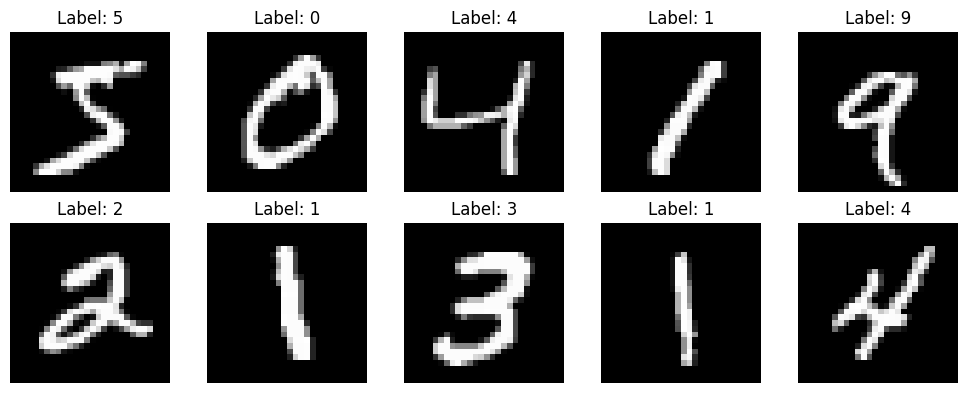

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, (img, label) in zip(axes.flat, train_dataset):
    # img is normalised, so un-normalise just for display
    ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [5]:
class Perceptron(nn.Module):
    """A simple feed-forward neural network for MNIST classification."""

    def __init__(self, input_size: int = 784, hidden1: int = 128,
                 hidden2: int = 64, num_classes: int = 10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        x = self.flatten(x)            # (B, 1, 28, 28) -> (B, 784)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)                # raw logits, no softmax
        return x


# Instantiate and move to GPU/CPU
model = Perceptron().to(device)
print(model)

# How many trainable parameters does this model have?
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")


Perceptron(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

Trainable parameters: 109,386


In [6]:
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Loss:      {criterion}")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")


Loss:      CrossEntropyLoss()
Optimizer: Adam (lr=0.001)


In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # 1. zero gradients
        optimizer.zero_grad()
        # 2. forward
        outputs = model(images)
        # 3. loss
        loss = criterion(outputs, labels)
        # 4. backward
        loss.backward()
        # 5. update weights
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


In [8]:
EPOCHS = 5

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"train loss {train_loss:.4f}  acc {train_acc*100:5.2f}% | "
          f"test loss {test_loss:.4f}  acc {test_acc*100:5.2f}%")

elapsed = time.time() - start_time
print(f"\nTotal training time: {elapsed:.2f} seconds on {device}")


Epoch  1/5 | train loss 0.2646  acc 92.15% | test loss 0.1546  acc 95.25%
Epoch  2/5 | train loss 0.1101  acc 96.65% | test loss 0.1050  acc 96.73%
Epoch  3/5 | train loss 0.0803  acc 97.50% | test loss 0.0829  acc 97.33%
Epoch  4/5 | train loss 0.0618  acc 97.99% | test loss 0.0938  acc 97.14%
Epoch  5/5 | train loss 0.0488  acc 98.40% | test loss 0.0803  acc 97.54%

Total training time: 75.01 seconds on cuda:0


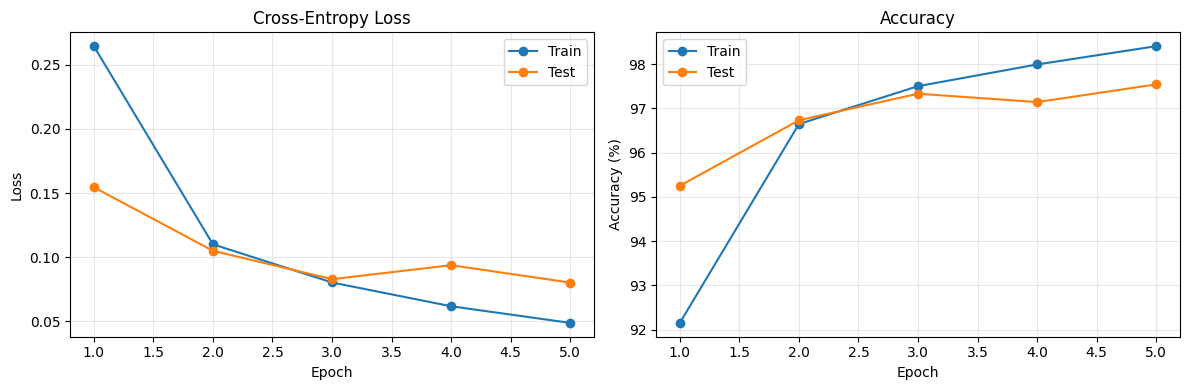

In [9]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train")
axes[0].plot(epochs_range, history["test_loss"],  "o-", label="Test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a * 100 for a in history["train_acc"]], "o-", label="Train")
axes[1].plot(epochs_range, [a * 100 for a in history["test_acc"]],  "o-", label="Test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


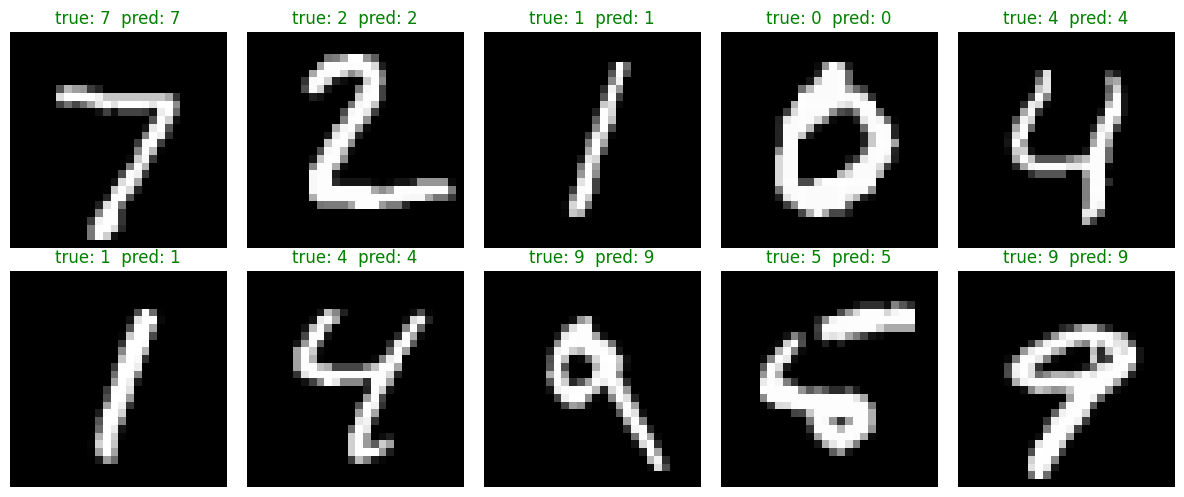

In [10]:
model.eval()
images, labels = next(iter(test_loader))
images_dev = images.to(device)

with torch.no_grad():
    outputs = model(images_dev)
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, true, pred in zip(axes.flat, images, labels, preds):
    ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap="gray")
    color = "green" if pred == true else "red"
    ax.set_title(f"true: {true.item()}  pred: {pred.item()}", color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()


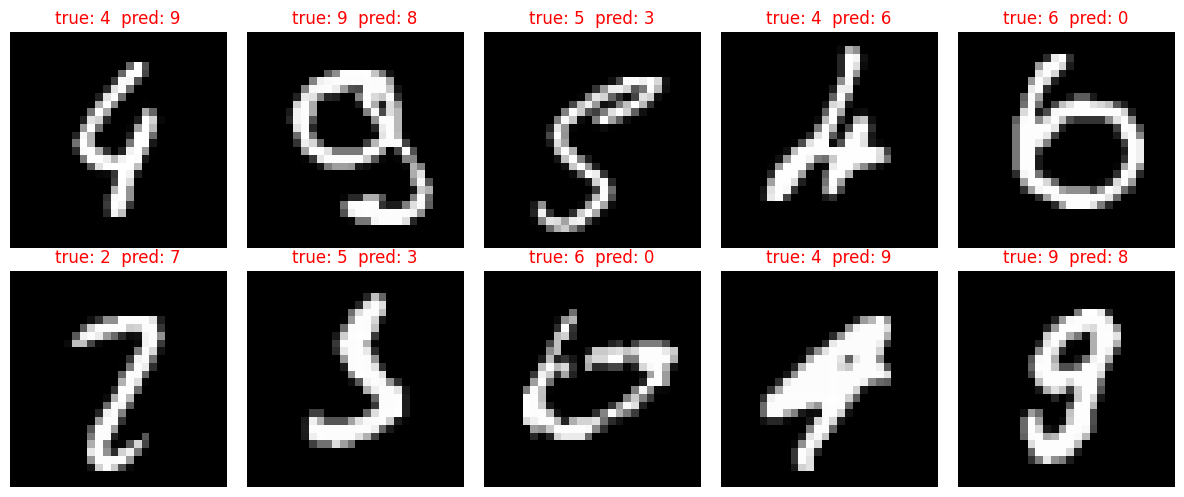

In [11]:
# Collect misclassified samples from the test set
model.eval()
wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(dim=1).cpu()
        mask = preds != labels
        if mask.any():
            wrong_imgs.append(images[mask])
            wrong_true.append(labels[mask])
            wrong_pred.append(preds[mask])
        if sum(t.size(0) for t in wrong_imgs) >= 10:
            break

wrong_imgs = torch.cat(wrong_imgs)[:10]
wrong_true = torch.cat(wrong_true)[:10]
wrong_pred = torch.cat(wrong_pred)[:10]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, t, p in zip(axes.flat, wrong_imgs, wrong_true, wrong_pred):
    ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap="gray")
    ax.set_title(f"true: {t.item()}  pred: {p.item()}", color="red")
    ax.axis("off")
plt.tight_layout()
plt.show()
